# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [ ]:
%pip install --upgrade plotly

     |████████████████████████████████| 13.1MB 310kB/s 
  Found existing installation: plotly 4.4.1
    Uninstalling plotly-4.4.1:
      Successfully uninstalled plotly-4.4.1


## Import Statements

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [3]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('deaths_by_police_us.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [4]:
dataframes = [df_hh_income,df_pct_poverty,df_pct_completed_hs,df_share_race_city,df_fatalities]
for df in dataframes:
    print(df.shape[0])
    print(df.shape[1])
    print(df.columns)
    print(df.isnull().sum())
    print(df.duplicated().sum())

29322
3
Index(['Geographic Area', 'City', 'Median Income'], dtype='object')
Geographic Area     0
City                0
Median Income      51
dtype: int64
0
29329
3
Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')
Geographic Area    0
City               0
poverty_rate       0
dtype: int64
0
29329
3
Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
0
29268
7
Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64
0
2535
14
Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_l

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [5]:
for df in [df_hh_income, df_pct_poverty, df_pct_completed_hs, df_share_race_city]:
    df.replace(['-', '(X)'], np.nan, inplace=True)

In [9]:
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'],errors='coerce')
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'],errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'],errors='coerce')

race_columns = [
    'share_white',
    'share_black',
    'share_native_american',
    'share_asian',
    'share_hispanic'
]

for column in race_columns:
    df_share_race_city[column] = pd.to_numeric(df_share_race_city[column],errors='coerce')


In [11]:
for df in dataframes:
    print(df.isna().sum())

Geographic Area       0
City                  0
Median Income      1937
dtype: int64
Geographic Area      0
City                 0
poverty_rate       201
dtype: int64
Geographic Area           0
City                      0
percent_completed_hs    197
dtype: int64
Geographic area           0
City                      0
share_white              20
share_black              20
share_native_american    20
share_asian              20
share_hispanic           20
dtype: int64
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

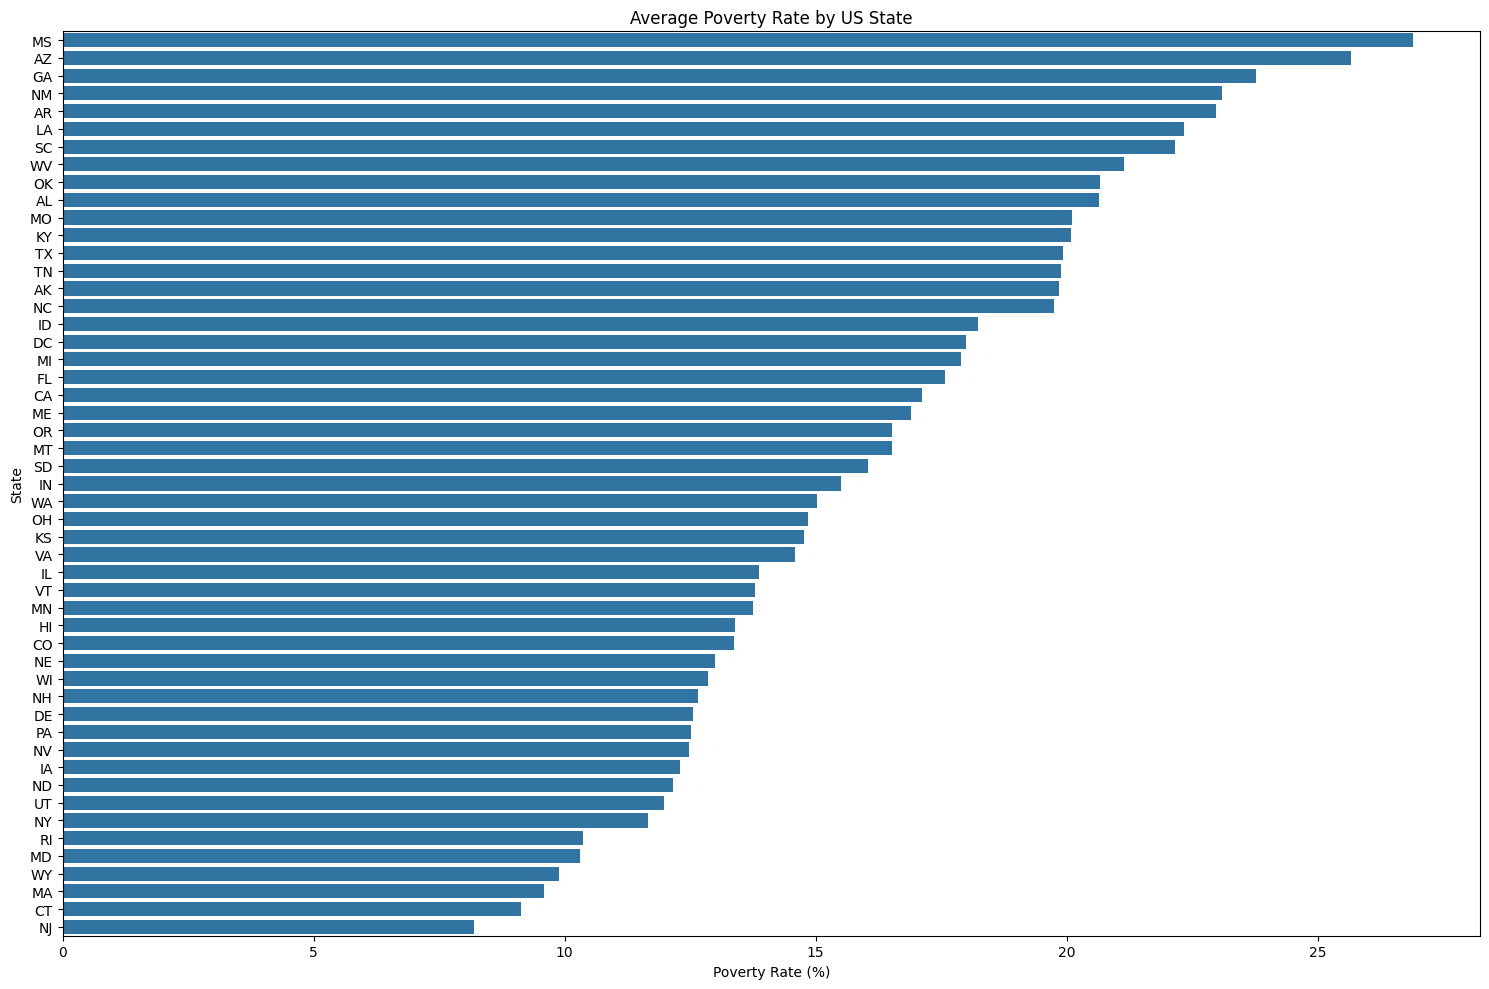

In [12]:
state_poverty = (df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False))

plt.figure(figsize=(15, 10))

sns.barplot(x=state_poverty.values,y=state_poverty.index)

plt.title('Average Poverty Rate by US State')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('State')
plt.tight_layout()

plt.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

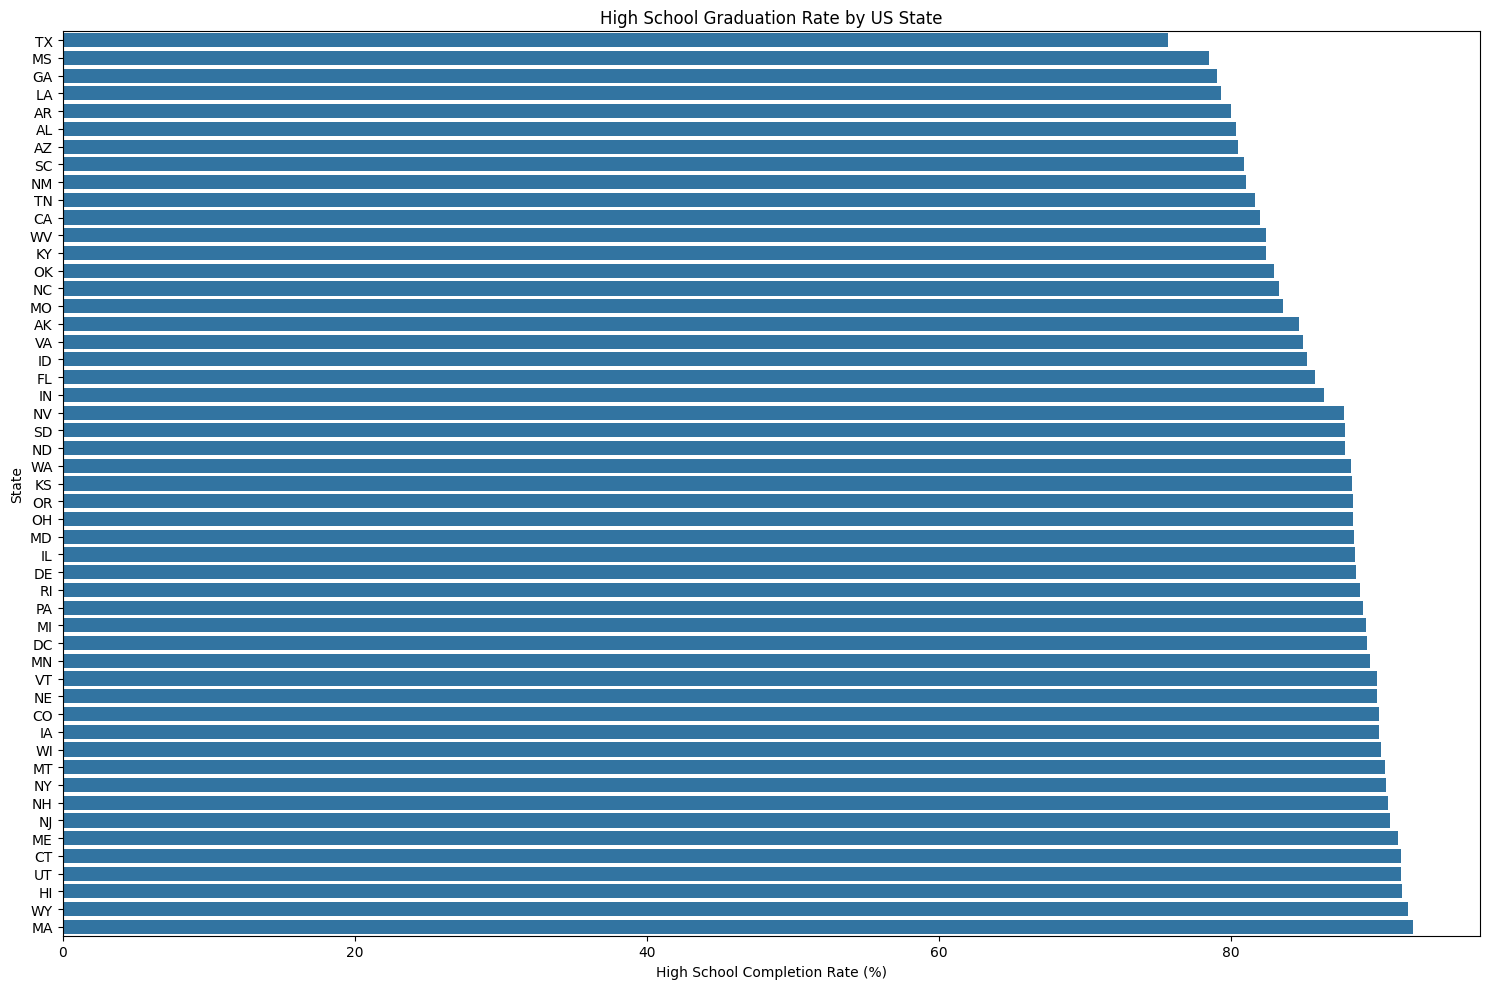

In [13]:
state_hs = (df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values())

plt.figure(figsize=(15, 10))

sns.barplot(x=state_hs.values,y=state_hs.index)

plt.title('High School Graduation Rate by US State')
plt.xlabel('High School Completion Rate (%)')
plt.ylabel('State')
plt.tight_layout()

plt.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

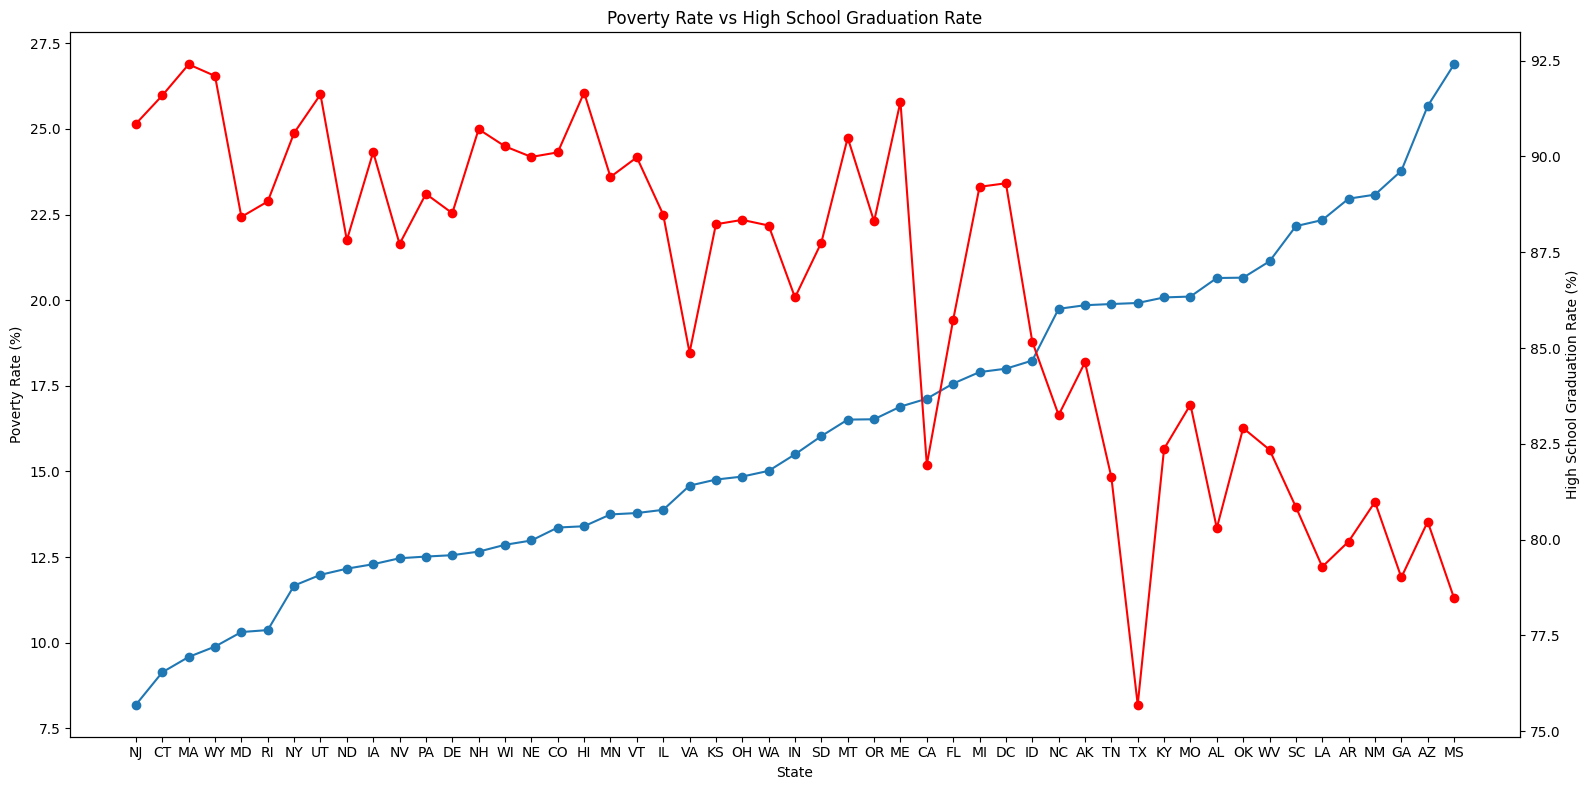

In [16]:
state_education_poverty = pd.DataFrame({'poverty_rate': state_poverty,'high_school_rate': state_hs}).dropna()

state_education_poverty = state_education_poverty.sort_values('poverty_rate')

fig, ax1 = plt.subplots(figsize=(16, 8))

ax1.plot(
    state_education_poverty.index,
    state_education_poverty['poverty_rate'],
    marker='o',

    label='Poverty Rate'
)

ax1.set_xlabel('State')
ax1.set_ylabel('Poverty Rate (%)')

ax2 = ax1.twinx()

ax2.plot(
    state_education_poverty.index,
    state_education_poverty['high_school_rate'],
    marker='o',
    color = 'red',
    label='High School Graduation Rate'
)

ax2.set_ylabel('High School Graduation Rate (%)')

plt.title('Poverty Rate vs High School Graduation Rate')
plt.xticks(rotation=90)

fig.tight_layout()
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

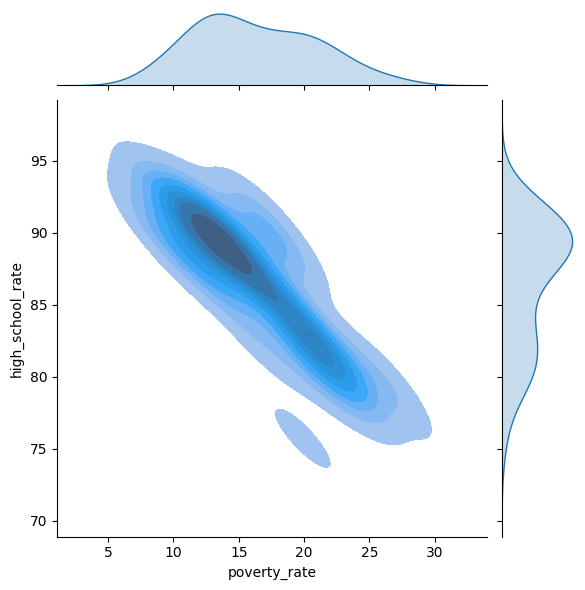

In [17]:
sns.jointplot(
    data=state_education_poverty,
    x='poverty_rate',
    y='high_school_rate',
    kind='kde',
    fill=True
)

plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

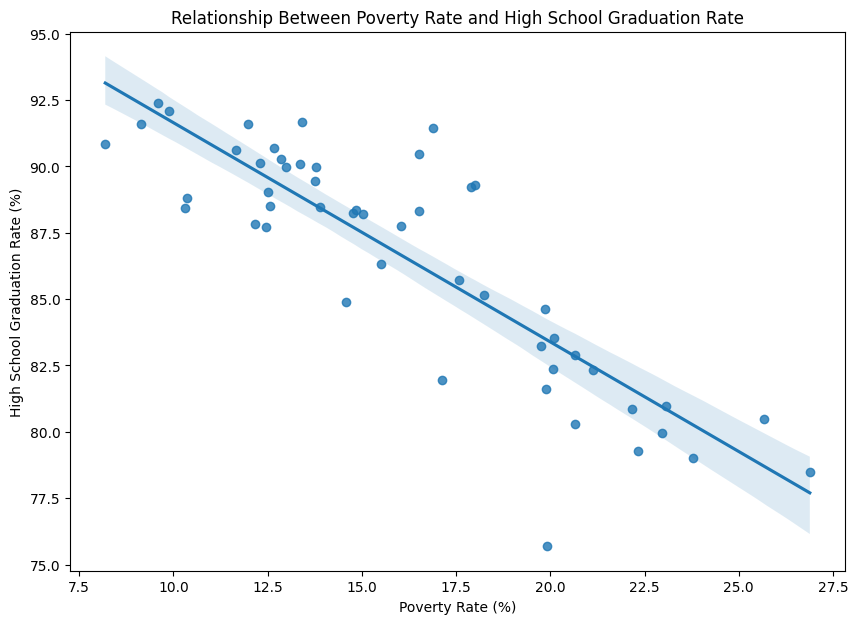

In [19]:
plt.figure(figsize=(10, 7))

sns.regplot(data=state_education_poverty,
            x='poverty_rate',
            y='high_school_rate'
            )

plt.title('Relationship Between Poverty Rate and High School Graduation Rate')

plt.xlabel('Poverty Rate (%)')
plt.ylabel('High School Graduation Rate (%)')

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

<Figure size 1800x1200 with 0 Axes>

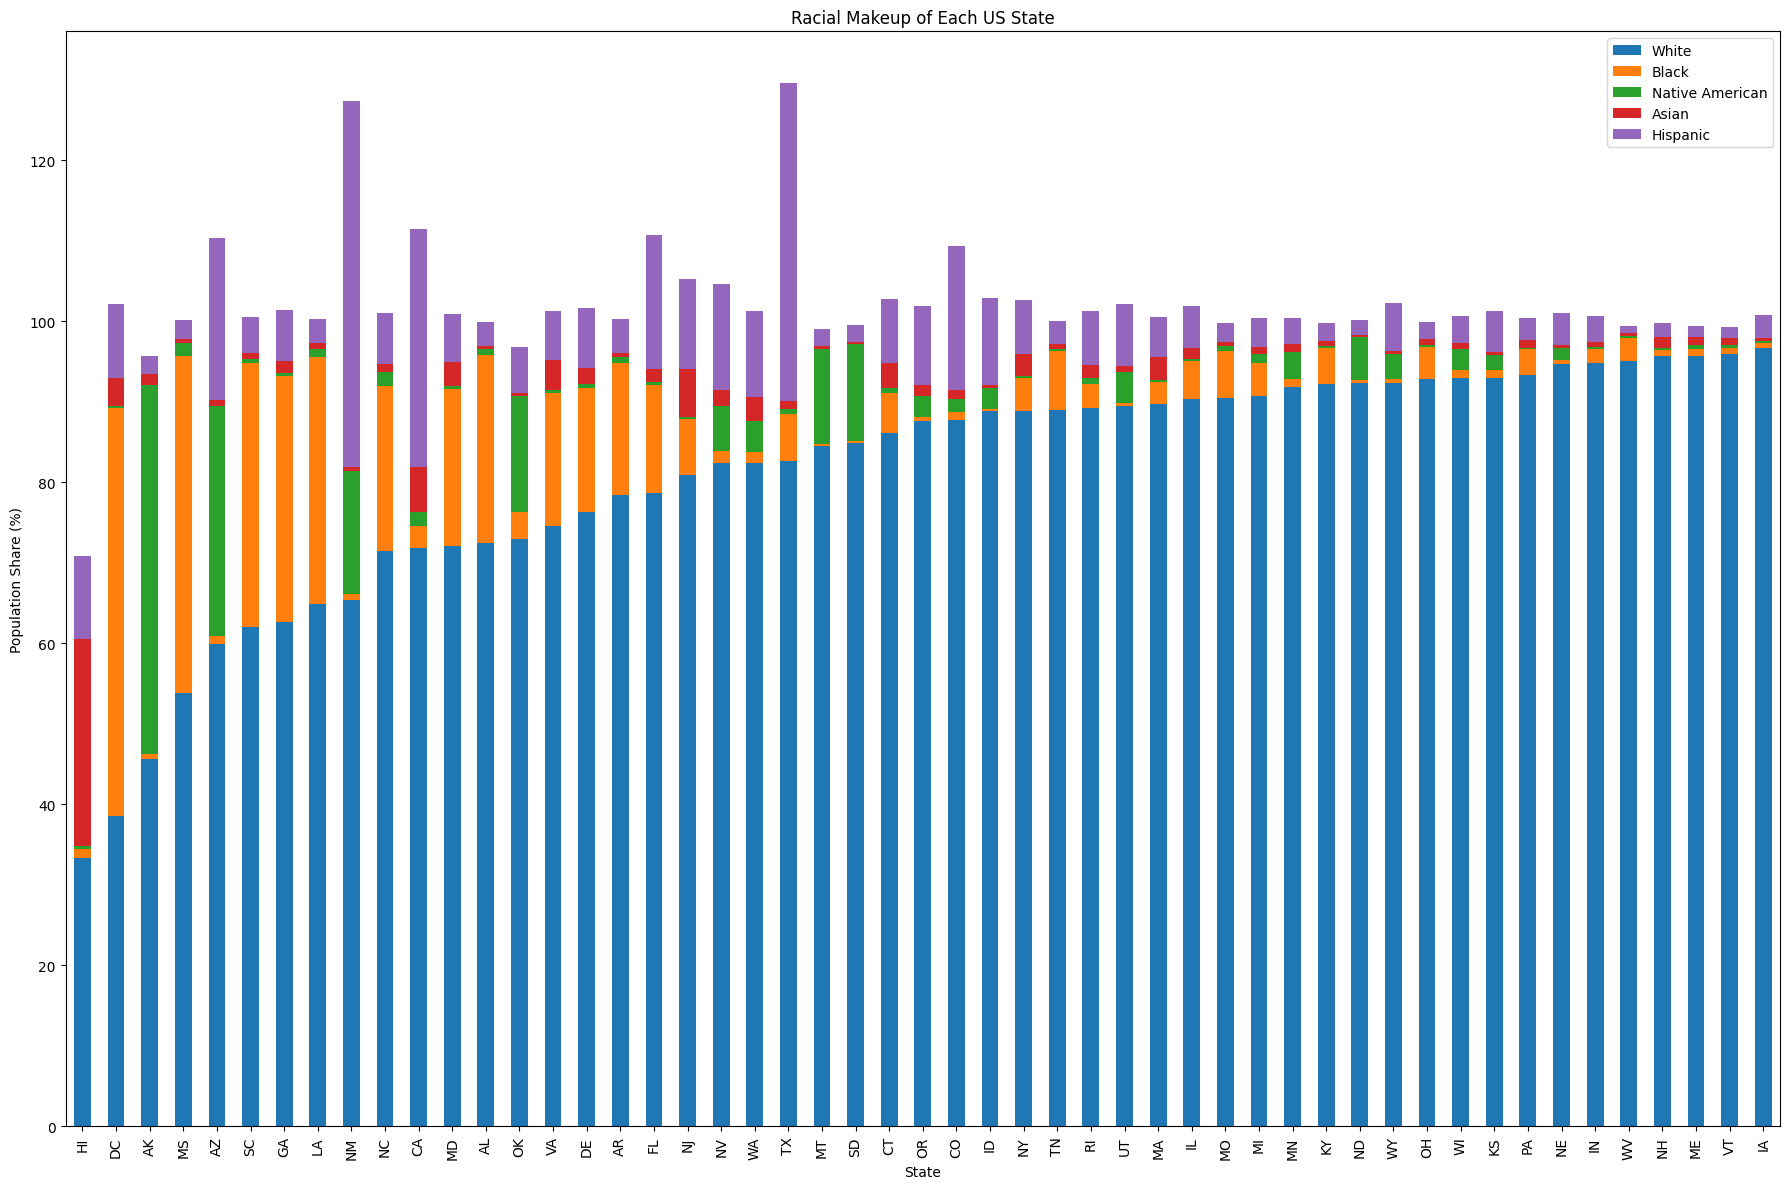

In [20]:
state_race = (df_share_race_city.groupby('Geographic area')[[
            'share_white',
            'share_black',
            'share_native_american',
            'share_asian',
            'share_hispanic'
        ]].mean()
)

state_race = state_race.sort_values('share_white')

plt.figure(figsize=(18, 12))

state_race.plot(
    kind='bar',
    stacked=True,
    figsize=(18, 12)
)

plt.title('Racial Makeup of Each US State')
plt.xlabel('State')
plt.ylabel('Population Share (%)')
plt.legend(
    [
        'White',
        'Black',
        'Native American',
        'Asian',
        'Hispanic'
    ]
)

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

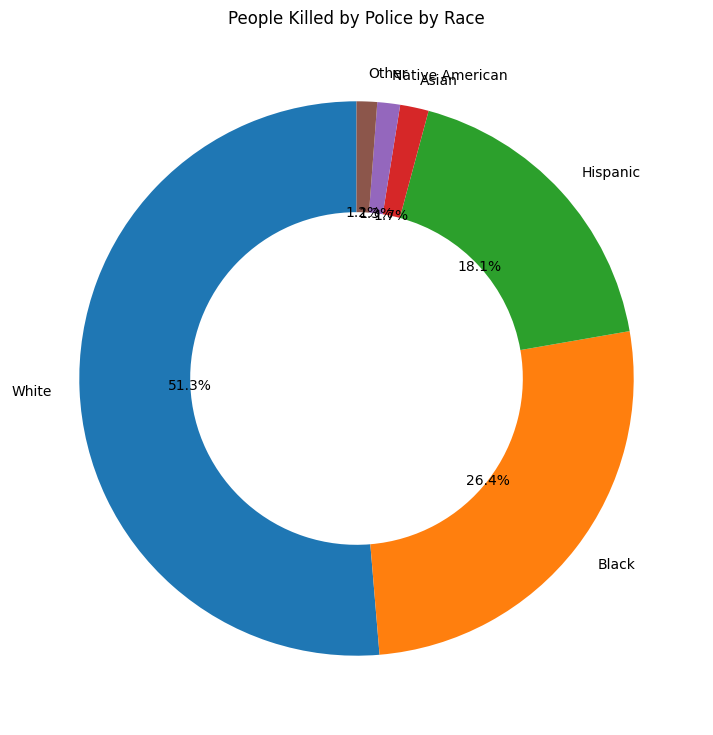

In [23]:
race_counts = df_fatalities['race'].value_counts()

race_labels = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other'
}

race_counts.index = race_counts.index.map(lambda x: race_labels.get(x, 'Unknown'))

plt.figure(figsize=(9, 9))

plt.pie(
    race_counts,
    labels=race_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('People Killed by Police by Race')

plt.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

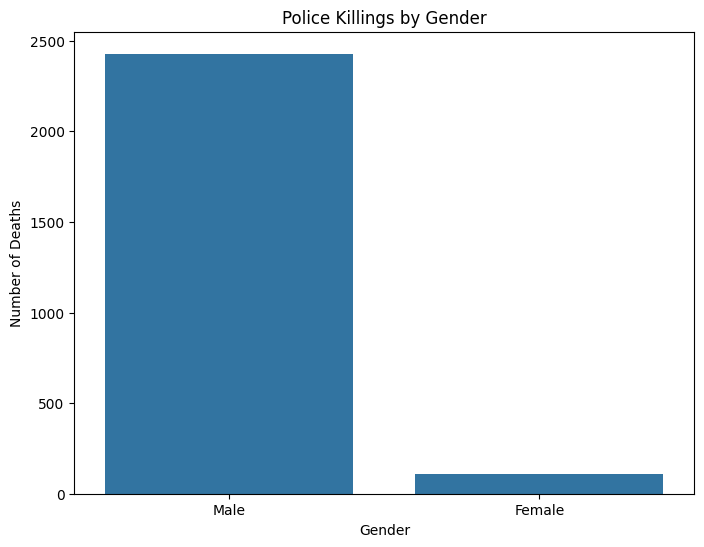

gender
Male      2428
Female     107
Name: count, dtype: int64
More men than women: 2321


In [24]:
gender_counts = df_fatalities['gender'].value_counts()

gender_counts.index = gender_counts.index.map({'M': 'Male','F': 'Female'})

plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title('Police Killings by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Deaths')

plt.show()

print(gender_counts)

male_deaths = gender_counts.get('Male', 0)
female_deaths = gender_counts.get('Female', 0)

print(f"More men than women: {male_deaths - female_deaths}")

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

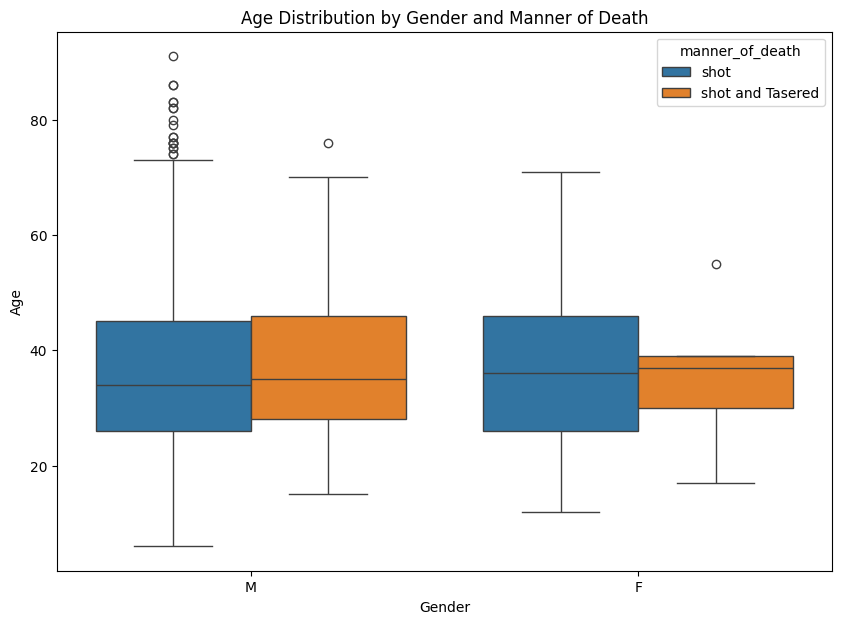

In [25]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df_fatalities,
    x='gender',
    y='age',
    hue='manner_of_death'
)

plt.title('Age Distribution by Gender and Manner of Death')
plt.xlabel('Gender')
plt.ylabel('Age')

plt.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

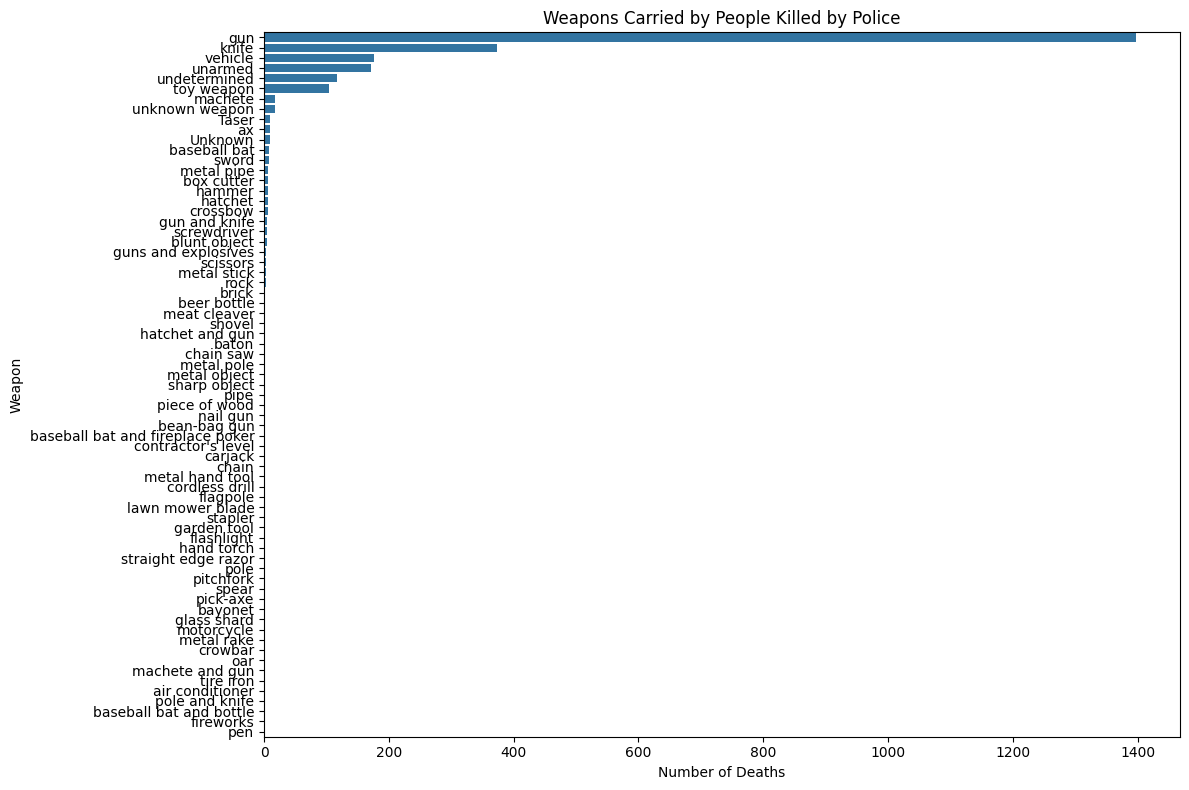

In [26]:
armed_counts = df_fatalities['armed'].fillna('Unknown').value_counts()

plt.figure(figsize=(12, 8))

sns.barplot(
    x=armed_counts.values,
    y=armed_counts.index
)

plt.title('Weapons Carried by People Killed by Police')
plt.xlabel('Number of Deaths')
plt.ylabel('Weapon')

plt.tight_layout()
plt.show()

Armed with guns: 1411
Unarmed: 171


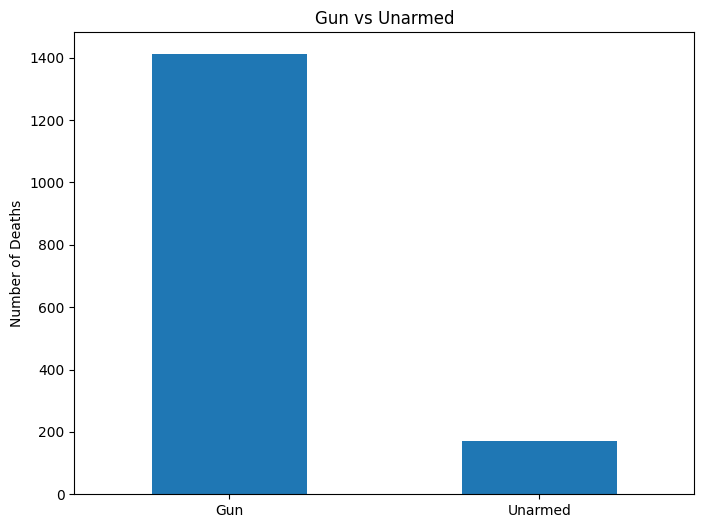

In [ ]:
gun_count = (
    df_fatalities['armed'].fillna('').str.contains('gun', case=False).sum())

unarmed_count = (df_fatalities['armed'] == 'unarmed').sum()

print(f"Armed with guns: {gun_count}")
print(f"Unarmed: {unarmed_count}")

comparison = pd.Series({'Gun': gun_count,'Unarmed': unarmed_count})

comparison.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('Gun vs Unarmed')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)

plt.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [28]:
under_25 = (df_fatalities['age'] < 25).sum()

percentage_under_25 = (
    under_25 / len(df_fatalities)
) * 100

print(f"Number of people under 25: {under_25}")
print(f"Percentage of people killed who were under 25: "
      f"{percentage_under_25:.2f}%")

Number of people under 25: 450
Percentage of people killed who were under 25: 17.75%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

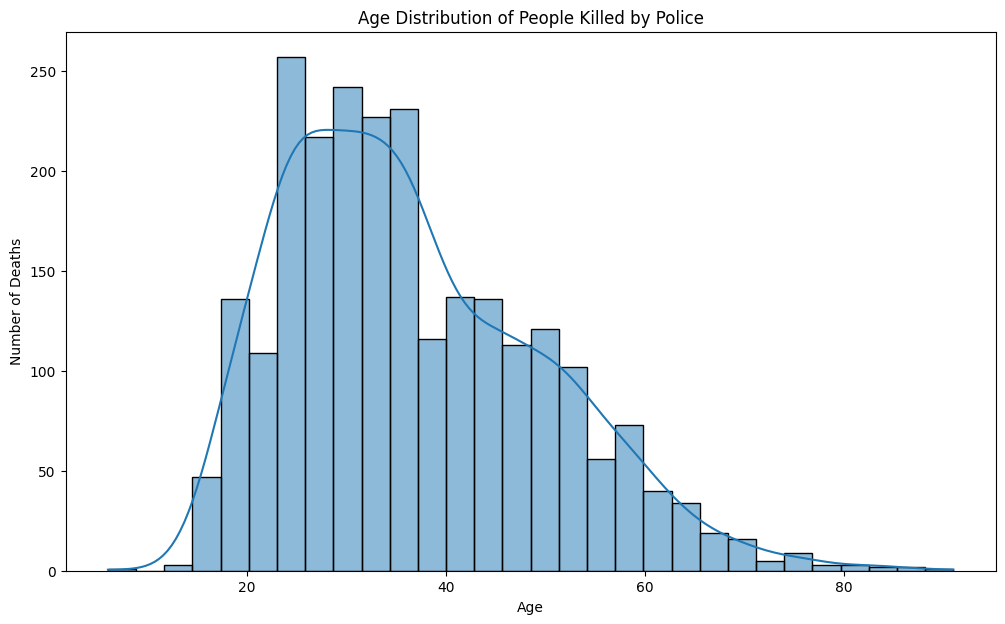

In [29]:
plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_fatalities,
    x='age',
    bins=30,
    kde=True
)

plt.title('Age Distribution of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Number of Deaths')

plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

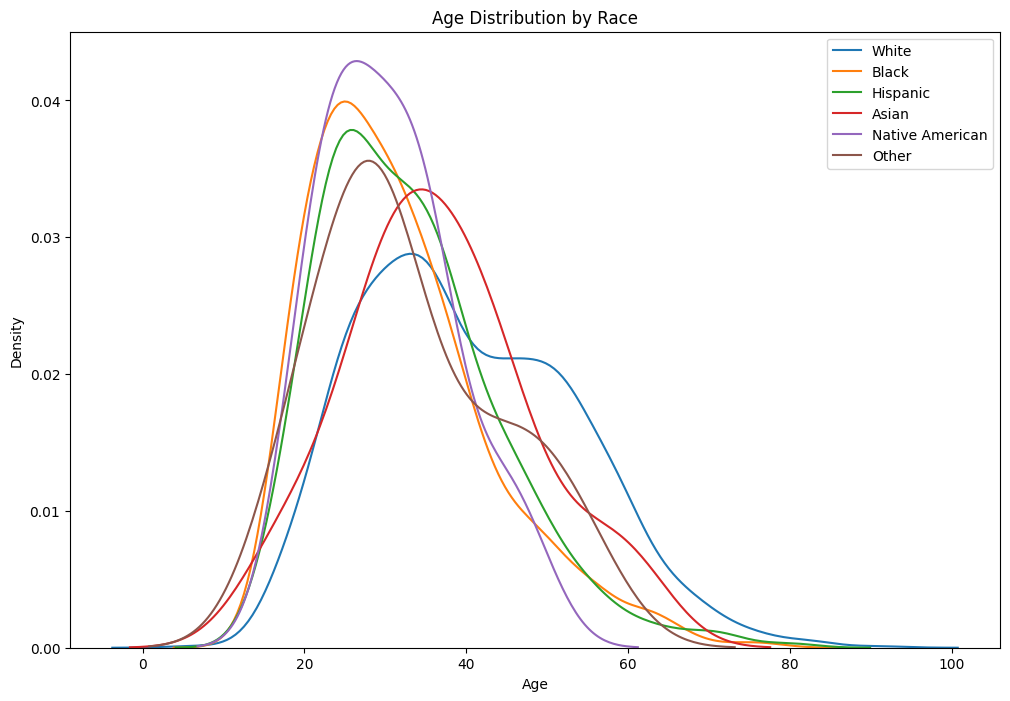

In [30]:
race_labels = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other'
}

plt.figure(figsize=(12, 8))

for race_code, race_name in race_labels.items():

    race_age = df_fatalities.loc[df_fatalities['race'] == race_code,'age'].dropna()

    if len(race_age) > 1:
        sns.kdeplot(
            race_age,
            label=race_name,
            fill=False
        )

plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()

plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

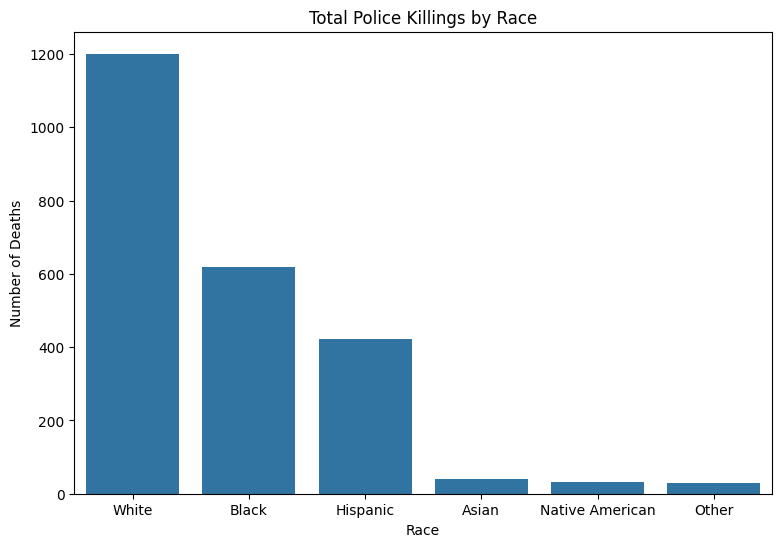

In [31]:
race_counts = df_fatalities['race'].value_counts()

race_counts.index = race_counts.index.map(
    lambda x: race_labels.get(x, 'Unknown')
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=race_counts.index,
    y=race_counts.values
)

plt.title('Total Police Killings by Race')
plt.xlabel('Race')
plt.ylabel('Number of Deaths')

plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

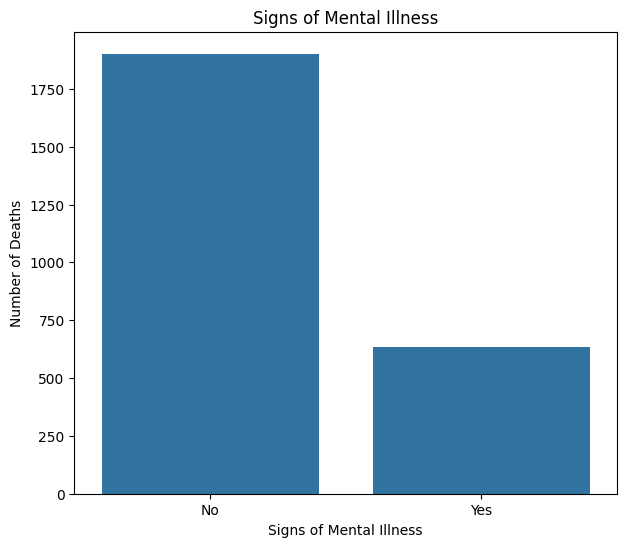

In [32]:
mental_counts = (
    df_fatalities['signs_of_mental_illness']
    .map({
        True: 'Yes',
        False: 'No'
    })
    .value_counts()
)

plt.figure(figsize=(7, 6))

sns.barplot(
    x=mental_counts.index,
    y=mental_counts.values
)

plt.title('Signs of Mental Illness')
plt.xlabel('Signs of Mental Illness')
plt.ylabel('Number of Deaths')

plt.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [33]:
top_10_cities = (
    df_fatalities
    .groupby(['city', 'state'])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='killings')
)

print(top_10_cities)

          city state  killings
0  Los Angeles    CA        39
1      Phoenix    AZ        31
2      Houston    TX        26
3      Chicago    IL        25
4    Las Vegas    NV        21
5  San Antonio    TX        20
6        Miami    FL        17
7     Columbus    OH        17
8       Austin    TX        16
9    St. Louis    MO        15


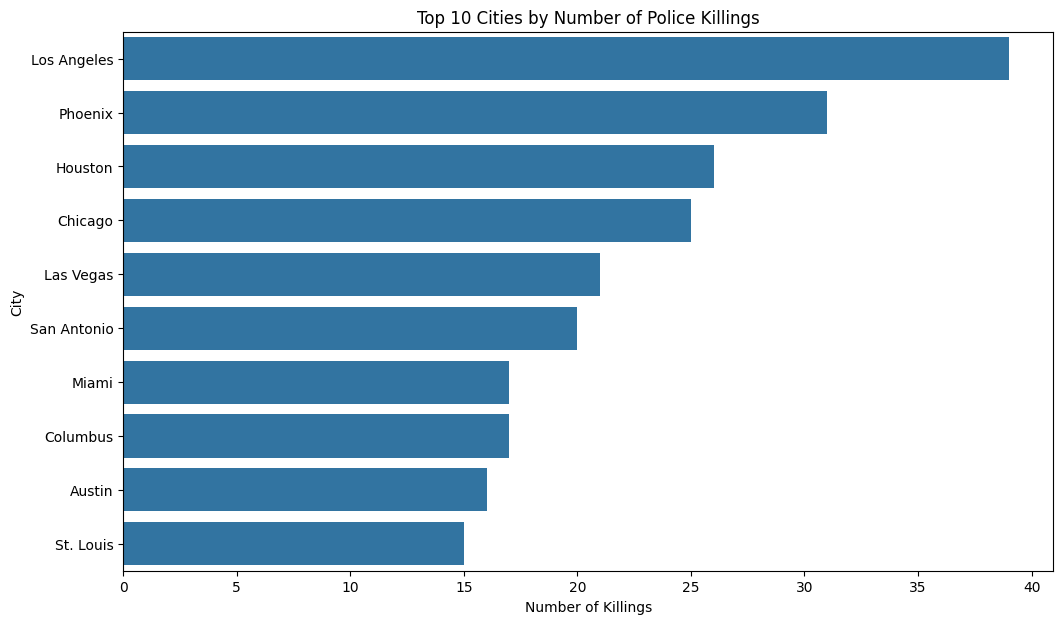

In [34]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_cities,
    x='killings',
    y='city'
)

plt.title('Top 10 Cities by Number of Police Killings')
plt.xlabel('Number of Killings')
plt.ylabel('City')

plt.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [35]:
race_city = df_share_race_city.copy()

race_city['city_clean'] = (
    race_city['City']
    .str.replace(
        r'\s+(city|town|village|borough|CDP|municipality)$',
        '',
        regex=True
    )
    .str.strip()
)

In [36]:
race_code_to_column = {
    'W': 'share_white',
    'B': 'share_black',
    'H': 'share_hispanic',
    'A': 'share_asian',
    'N': 'share_native_american'
}

top_cities = top_10_cities.copy()

results = []

for _, row in top_cities.iterrows():

    city = row['city']
    state = row['state']
    total_killings = row['killings']

    city_deaths = df_fatalities[
        (df_fatalities['city'] == city) &
        (df_fatalities['state'] == state)
    ]

    census_row = race_city[
        (race_city['city_clean'] == city) &
        (race_city['Geographic area'] == state)
    ]

    if census_row.empty:
        continue

    census_row = census_row.iloc[0]

    for race_code, census_column in race_code_to_column.items():

        deaths = (
            city_deaths['race'] == race_code
        ).sum()

        population_share = census_row[census_column]

        death_share = (
            deaths / total_killings
        ) * 100

        if population_share and not pd.isna(population_share):
            relative_rate = (
                death_share / population_share
            )
        else:
            relative_rate = np.nan

        results.append({
            'city': city,
            'state': state,
            'race': race_code,
            'deaths': deaths,
            'population_share': population_share,
            'death_share': death_share,
            'relative_rate': relative_rate
        })

race_rate_df = pd.DataFrame(results)

race_rate_df

,city,state,race,deaths,population_share,death_share,relative_rate
0,Los Angeles,CA,W,6,49.80,15.38,0.31
1,Los Angeles,CA,B,10,9.60,25.64,2.67
2,Los Angeles,CA,H,19,48.50,48.72,1.00
3,Los Angeles,CA,A,1,11.30,2.56,0.23
4,Los Angeles,CA,N,0,0.70,0.00,0.00
5,Phoenix,AZ,W,12,65.90,38.71,0.59
6,Phoenix,AZ,B,2,6.50,6.45,0.99
7,Phoenix,AZ,H,11,40.80,35.48,0.87
8,Phoenix,AZ,A,0,3.20,0.00,0.00
9,Phoenix,AZ,N,3,2.20,9.68,4.40


In [ ]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=race_rate_df,
    x='city',
    y='relative_rate',
    hue='race'
)

plt.axhline(1,linestyle='--')

plt.title('Relative Police Killing Rate by Race in the Top 10 Cities')

plt.xlabel('City')
plt.ylabel('Killing Share / Population Share')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [37]:
state_killings = (
    df_fatalities['state']
    .value_counts()
    .reset_index()
)

state_killings.columns = ['state', 'killings']

state_killings

,state,killings
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79
5,OK,78
6,CO,74
7,GA,70
8,NC,69
9,MO,64


In [38]:
fig = px.choropleth(
    state_killings,
    locations='state',
    locationmode='USA-states',
    color='killings',
    scope='usa',
    color_continuous_scale='Reds',
    title='Police Killings by US State'
)

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [39]:
state_comparison = pd.merge(
    state_killings,
    state_poverty.reset_index(),
    left_on='state',
    right_on='Geographic Area'
)

state_comparison = state_comparison[
    ['state', 'killings', 'poverty_rate']
].sort_values(
    'killings',
    ascending=False
)

state_comparison.head(10)

,state,killings,poverty_rate
0,CA,424,17.12
1,TX,225,19.92
2,FL,154,17.57
3,AZ,118,25.67
4,OH,79,14.85
5,OK,78,20.66
6,CO,74,13.36
7,GA,70,23.78
8,NC,69,19.75
9,MO,64,20.11


In [ ]:
state_correlation = state_comparison['killings'].corr(
    state_comparison['poverty_rate']
)

print(
    f"Correlation between total killings "
    f"and average poverty rate: "
    f"{state_correlation:.3f}"
)

In [40]:
df_fatalities['date'] = pd.to_datetime(
    df_fatalities['date'],
    format='%d/%m/%y'
)

daily_killings = (
    df_fatalities
    .groupby('date')
    .size()
    .reset_index(name='killings')
)

daily_killings.head()

,date,killings
0,2015-01-02,2
1,2015-01-03,1
2,2015-01-04,3
3,2015-01-05,1
4,2015-01-06,4


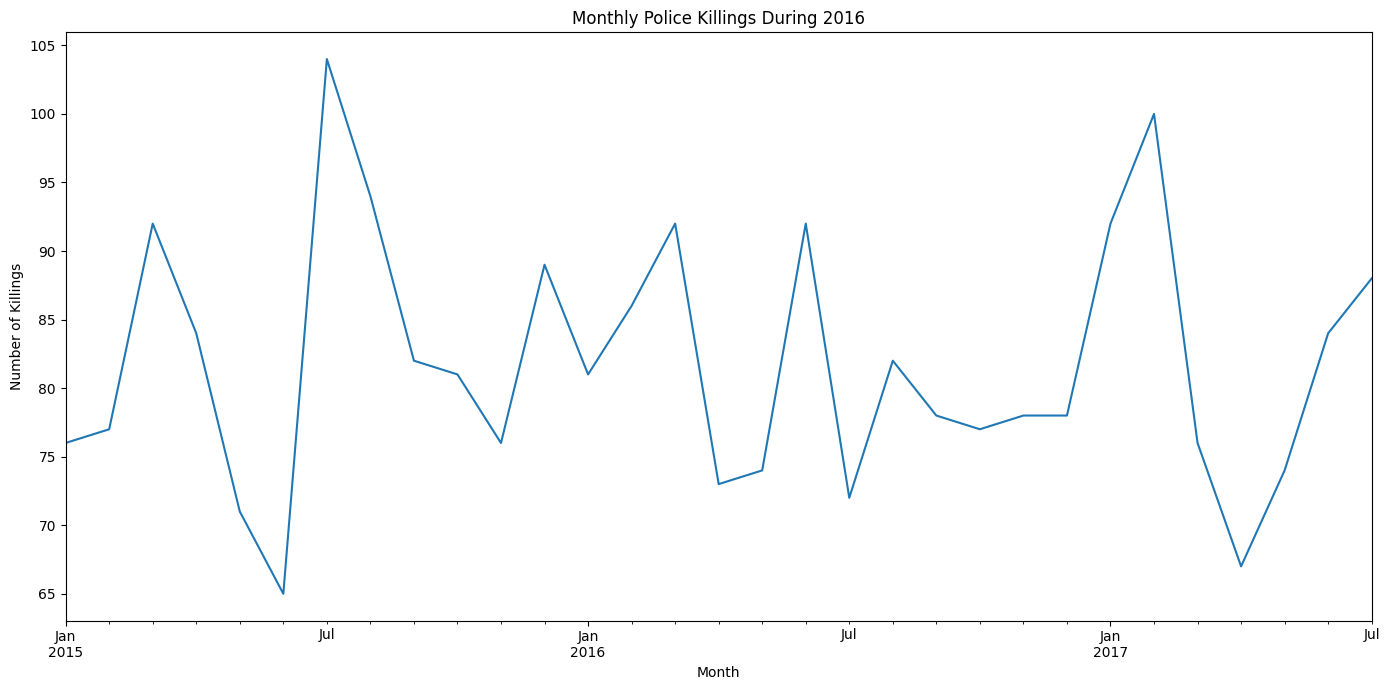

In [42]:
monthly_killings = (
    df_fatalities
    .set_index('date')
    .resample('ME')
    .size()
)

plt.figure(figsize=(14, 7))

monthly_killings.plot()

plt.title('Monthly Police Killings During 2016')
plt.xlabel('Month')
plt.ylabel('Number of Killings')

plt.tight_layout()

plt.show()